In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split

## Improrting CSV file

In [339]:
df = pd.read_csv('Student Social Media And Mental Health Impact.csv')

## Looking for no. of rows and columns

In [340]:
df.shape

(5000, 13)

## Printing First five rows

In [341]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


## Checking for null values

In [342]:
df.isnull().sum()

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


## Checking for duplicate values

In [343]:
df.duplicated().sum()

np.int64(2)

In [344]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


## Generating descriptive statistics

In [345]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [346]:
df[df['Physical_Activity_Hours'] < 0].shape

(10, 13)

## 2) Expolatory Data Analysis (EDA)

#### 2.1) Checking the distribution of target column

Before going further we need to understand the distribution of what we are predicting

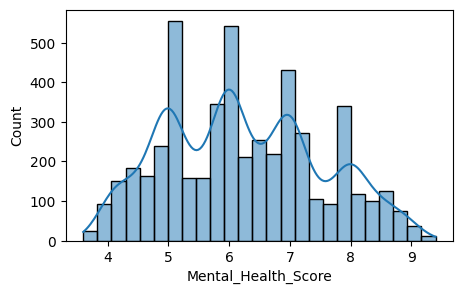

In [347]:
plt.figure(figsize=(5,3))
sns.histplot(df['Mental_Health_Score'], kde=True)
plt.show()

#### 2.2) Checking coorelation

Checking which column moves with target column

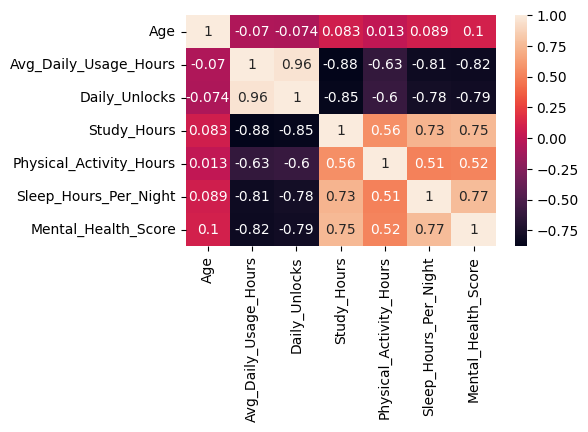

In [348]:
plt.figure(figsize=(5,3))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [349]:
# df.drop(columns=['Daily_Unlocks'], inplace=True)

#### 2.3) Stress level vs Mental health score

In [350]:
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

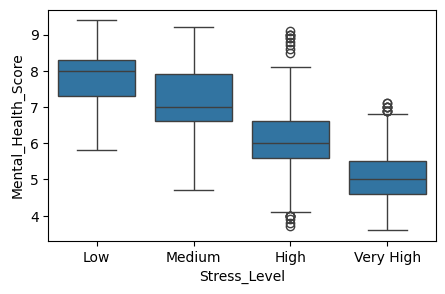

In [351]:
order = ['Low', 'Medium', 'High', 'Very High']
plt.figure(figsize=(5,3))
sns.boxplot(x='Stress_Level', y='Mental_Health_Score', data=df, order=order)
plt.show()
## It has some outliers that we will handel later

#### 2.4) Daily usage hours vs Mental health score

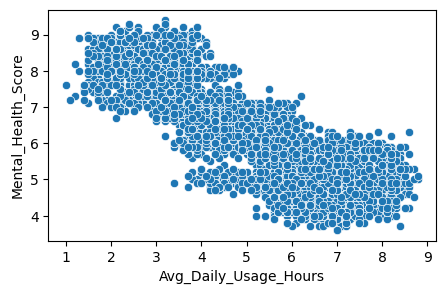

In [352]:
plt.figure(figsize=(5,3))
sns.scatterplot(data=df, x='Avg_Daily_Usage_Hours', y='Mental_Health_Score')
plt.show()

#### 2.5) Sleep hours vs Mental Health score

In [353]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


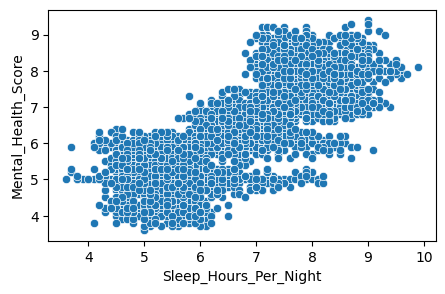

In [354]:
plt.figure(figsize=(5,3))
sns.scatterplot(x='Sleep_Hours_Per_Night', y='Mental_Health_Score', data=df)
plt.show()

#### 2.6) Checking Outliers - Using IQR (Inter Quartile Range)

In [355]:
num_features = df.select_dtypes(include=['number'])

In [356]:
Q1 = num_features.quantile(0.25)
Q3 = num_features.quantile(0.75)
IQR = Q3 - Q1
lower_bond = Q1 - 1.5 * IQR
upper_bond = Q3 + 1.5 * IQR

In [357]:
outliers = (num_features < lower_bond) | (num_features > upper_bond)

In [358]:
outliers.sum()

,0
Age,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,2
Physical_Activity_Hours,22
Sleep_Hours_Per_Night,0
Mental_Health_Score,0


## 4) Data Cleaning

#### 4.1) To Drop DUplicates

In [360]:
df.drop_duplicates(inplace=True)

In [361]:
df.duplicated().sum()

np.int64(0)

#### 4.2) clipping the impossible values of column Physical_Activity_Hours to it nearest possible value

In [362]:
df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=0)

In [364]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


## 5) Skewness

#### 5.1) Checking skewness of each column

In [365]:
df.skew(numeric_only=True)

,0
Age,0.155008
Avg_Daily_Usage_Hours,0.005575
Daily_Unlocks,0.002309
Study_Hours,0.436125
Physical_Activity_Hours,0.053288
Sleep_Hours_Per_Night,0.123919
Mental_Health_Score,0.207086


## 6) Feature Engineering

#### 6.1) Grouping Country Column

In [366]:
top_countries = df['Country'].value_counts().index[:15].tolist()

In [367]:
def group_countries(country):
    if country in top_countries:
        return country
    else:
        return 'Other'

In [368]:
df['Country'] = df['Country'].apply(group_countries)

## 7) Train Test Split

In [369]:
skewed_col = ['Study_Hours']
other_numeric_cols = ['Age', 'Avg_Daily_Usage_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night', 'Daily_Unlocks']
ordinal = ['Stress_Level']
onehot = ['Gender', 'Country', 'Academic_Level', 'Most_Used_Platform', 'Purpose_Of_Use']

In [370]:
feature_cols = skewed_col + other_numeric_cols + ordinal + onehot

In [371]:
X = df[feature_cols]
y = df['Mental_Health_Score']

In [372]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.25)

## 8) Creating Pipelines

#### 8.1) Pipeline for skewed feature

In [373]:
skewed_feature = Pipeline(steps=[
    ('log_transform', FunctionTransformer(func=np.log1p)),
    ('scaler', StandardScaler())
])

#### 8.2) Scaling numeric features

In [374]:
scaling_numeric = Pipeline(steps=[
    ('scale', StandardScaler())
])

#### 8.3) Ordinal encoding

In [375]:
ordinal_encode = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']]))
])

#### 8.4) One hot encoding

In [376]:
onehot_encoding = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

## 9) Creating column Transformer

In [422]:
proprocessor = ColumnTransformer(transformers=[
    ('skewed_pipeline', skewed_feature, skewed_col),
    ('scaling_pipeline', scaling_numeric, other_numeric_cols),
    ('ordinal_pipeline', ordinal_encode, ordinal),
    ('onehot_pipeline', onehot_encoding, onehot)
])

## 10) Build pipeline

#### Linear Regression

In [423]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [424]:
model = Pipeline(steps=[
    ('preprocessor', proprocessor),
    ('regressor', LinearRegression())
])

In [425]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('skewed_pipeline',
                                                  Pipeline(steps=[('log_transform',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Study_Hours']),
                                                 ('scaling_pipeline',
                                                  Pipeline(steps=[('scale',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Avg_Daily_Usage_Hours',
                                                   'Physical_Activity_Hours',
                                                   'Sleep_Hours_Per_Night',
                                                   'Daily_Unlocks']),
                                                 ('ordinal_pipeline',
                                                  Pipeline(steps=[('ordinal',
                                                                   OrdinalEncoder(categories=[['Low',
                                                                                               'Medium',
                                                                                               'High',
                                                                                               'Very '
                                                                                               'High']]))]),
                                                  ['Stress_Level']),
                                                 ('onehot_pipeline',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Country',
                                                   'Academic_Level',
                                                   'Most_Used_Platform',
                                                   'Purpose_Of_Use'])])),
                ('regressor', LinearRegression())])

In [426]:
y_pred = model.predict(X_test)

In [427]:
print("Training: ")
print(f"r2 score: {r2_score(model.predict(X_train), y_train)*100}")

Training: 
r2 score: 63.675673561938865


In [428]:
print("Testing: ")
print(f"r2 score: {r2_score(y_pred, y_test)*100}")
print(f"MSE: {mean_squared_error(y_pred, y_test)*100}")
print(f"MAE: {mean_absolute_error(y_pred, y_test)*100}")

Testing: 
r2 score: 63.990715779456664
MSE: 44.412758687430056
MAE: 52.21986348666917


#### Random Forest

In [429]:
from sklearn.ensemble import RandomForestRegressor

In [430]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', proprocessor),
    ('random forest', RandomForestRegressor(
        n_estimators=1000,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=4,
        max_features='sqrt',
        bootstrap=True,
        n_jobs=-1,
        random_state=42
    ))
])

In [431]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('skewed_pipeline',
                                                  Pipeline(steps=[('log_transform',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Study_Hours']),
                                                 ('scaling_pipeline',
                                                  Pipeline(steps=[('scale',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Avg_Daily_Usage_Hours',
                                                   'Physical_Activity_Hours',
                                                   'Sleep_Hours_Per_Night'...
                                                                                               'High']]))]),
                                                  ['Stress_Level']),
                                                 ('onehot_pipeline',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Country',
                                                   'Academic_Level',
                                                   'Most_Used_Platform',
                                                   'Purpose_Of_Use'])])),
                ('random forest',
                 RandomForestRegressor(max_depth=15, max_features='sqrt',
                                       min_samples_leaf=4, min_samples_split=10,
                                       n_estimators=1000, n_jobs=-1,
                                       random_state=42))])

In [433]:
print(f"Training r2 score: {r2_score(rf_pipeline.predict(X_train), y_train) * 100}")
print(f"Testing r2 score: {r2_score(rf_pipeline.predict(X_test), y_test) * 100}")

Training r2 score: 84.57226005212509
Testing r2 score: 77.71438538108382


### Hyperparameter Tuning for Random Forest

In [434]:
param_dist = {
    'random forest__n_estimators': [300, 500, 800, 1000, 1500],
    'random forest__max_depth': [8, 10, 12, 15, 20, None],
    'random forest__min_samples_split': [2, 5, 10, 15, 20],
    'random forest__min_samples_leaf': [1, 2, 4, 6, 8],
    'random forest__max_features': ['sqrt', 'log2', 0.5, 0.7],
    'random forest__bootstrap': [True]
}

In [435]:
from sklearn.model_selection import RandomizedSearchCV

search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

In [475]:
search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('skewed_pipeline',
                                                                               Pipeline(steps=[('log_transform',
                                                                                                FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Study_Hours']),
                                                                              ('scaling_pipeline',
                                                                               Pipeline(steps=[('scale',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Avg_Daily_Usage_Hours',
                                                                                'Physical_Activ...
                   param_distributions={'xgb__colsample_bytree': [0.6, 0.7, 0.8,
                                                                  0.9],
                                        'xgb__gamma': [0, 0.1, 0.3, 0.5],
                                        'xgb__learning_rate': [0.01, 0.03, 0.05,
                                                               0.1],
                                        'xgb__max_depth': [3, 4, 5, 6],
                                        'xgb__min_child_weight': [1, 3, 5, 7],
                                        'xgb__n_estimators': [300, 500, 800,
                                                              1200],
                                        'xgb__reg_alpha': [0, 0.1, 1, 5],
                                        'xgb__reg_lambda': [1, 2, 5, 10],
                                        'xgb__subsample': [0.6, 0.7, 0.8, 0.9]},
                   random_state=42, scoring='r2', verbose=2)

In [477]:
print(search.best_params_)
print(search.best_score_)

{'xgb__subsample': 0.9, 'xgb__reg_lambda': 2, 'xgb__reg_alpha': 0.1, 'xgb__n_estimators': 800, 'xgb__min_child_weight': 5, 'xgb__max_depth': 6, 'xgb__learning_rate': 0.1, 'xgb__gamma': 0, 'xgb__colsample_bytree': 0.6}
0.878339842448567


In [483]:
r2_score(search.best_estimator_.predict(X_test), y_test) * 100

88.18070024072522

## Trying Support Vector Regressor (SVR)

In [484]:
from sklearn.svm import SVR

In [485]:
svr = Pipeline(steps=[
    ('preprocessor', proprocessor),
    ('random forest', SVR(kernel='linear'))
])

In [486]:
svr.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('skewed_pipeline',
                                                  Pipeline(steps=[('log_transform',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Study_Hours']),
                                                 ('scaling_pipeline',
                                                  Pipeline(steps=[('scale',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Avg_Daily_Usage_Hours',
                                                   'Physical_Activity_Hours',
                                                   'Sleep_Hours_Per_Night',
                                                   'Daily_Unlocks']),
                                                 ('ordinal_pipeline',
                                                  Pipeline(steps=[('ordinal',
                                                                   OrdinalEncoder(categories=[['Low',
                                                                                               'Medium',
                                                                                               'High',
                                                                                               'Very '
                                                                                               'High']]))]),
                                                  ['Stress_Level']),
                                                 ('onehot_pipeline',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Country',
                                                   'Academic_Level',
                                                   'Most_Used_Platform',
                                                   'Purpose_Of_Use'])])),
                ('random forest', SVR(kernel='linear'))])

In [487]:
print(f"Training r2 score: {r2_score(svr.predict(X_train), y_train) * 100}")
print(f"Testing r2 score: {r2_score(svr.predict(X_test), y_test) * 100}")

Training r2 score: 61.884757180078665
Testing r2 score: 61.64978679699683


## Trying XGboost

In [489]:
from xgboost import XGBRegressor

In [490]:
xg = Pipeline(steps=[
    ('preprocessor', proprocessor),
    ('xgb', XGBRegressor(
        n_estimators=1200,
        learning_rate=0.1,
        max_depth=6,
        min_child_weight=1,
        subsample=0.8,
        colsample_bytree=0.6,
        gamma=0,
        reg_alpha=0.5,
        reg_lambda=1
    ))
])

In [491]:
xg.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('skewed_pipeline',
                                                  Pipeline(steps=[('log_transform',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Study_Hours']),
                                                 ('scaling_pipeline',
                                                  Pipeline(steps=[('scale',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Avg_Daily_Usage_Hours',
                                                   'Physical_Activity_Hours',
                                                   'Sleep_Hours_Per_Night'...
                              feature_types=None, feature_weights=None, gamma=0,
                              grow_policy=None, importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None, min_child_weight=1,
                              missing=nan, monotone_constraints=None,
                              multi_strategy=None, n_estimators=1200,
                              n_jobs=None, num_parallel_tree=None, ...))])

In [492]:
print(f"Training r2 score: {r2_score(xg.predict(X_train), y_train) * 100}")
print(f"Testing r2 score: {r2_score(xg.predict(X_test), y_test) * 100}")

Training r2 score: 99.56572206700659
Testing r2 score: 88.77830096228783


In [493]:
from sklearn.model_selection import cross_val_score

In [494]:
scores = cross_val_score(
    xg,
    X,
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print(scores)
print("Mean:", scores.mean())
print("Std:", scores.std())

[0.91823462 0.90184569 0.91695607 0.91400484 0.92266627]
Mean: 0.914741497446944
Std: 0.007024994714994253


## Saving the model

In [467]:
import joblib

In [468]:
joblib.dump(xg, filename='mental_health_model.pkl')

['mental_health_model.pkl']

In [469]:
model = joblib.load('mental_health_model.pkl')

In [470]:
model.predict(X_test)

array([5.059659 , 5.692337 , 4.12682  , ..., 4.9996257, 4.314971 ,
       6.3564534], dtype=float32)

In [474]:
r2_score(model.predict(X_test), y_test) * 100

88.77830096228783